In [1]:
from ucimlrepo import fetch_ucirepo, list_available_datasets
import pandas as pd
import numpy as np


In [2]:
list_available_datasets()

-------------------------------------
The following datasets are available:
-------------------------------------
Dataset Name                                                                            ID    
------------                                                                            --    
Abalone                                                                                 1     
Adult                                                                                   2     
Annealing                                                                               3     
Audiology (Standardized)                                                                8     
Auto MPG                                                                                9     
Automobile                                                                              10    
Balance Scale                                                                           12    
Balloons                       

In [3]:
heart_disease = fetch_ucirepo(id = 45)

In [4]:
X = heart_disease.data.features 
y = heart_disease.data.targets 

# metadata 
print(heart_disease.metadata) 

print(heart_disease.variables) 


{'uci_id': 45, 'name': 'Heart Disease', 'repository_url': 'https://archive.ics.uci.edu/dataset/45/heart+disease', 'data_url': 'https://archive.ics.uci.edu/static/public/45/data.csv', 'abstract': '4 databases: Cleveland, Hungary, Switzerland, and the VA Long Beach', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 303, 'num_features': 13, 'feature_types': ['Categorical', 'Integer', 'Real'], 'demographics': ['Age', 'Sex'], 'target_col': ['num'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 1989, 'last_updated': 'Fri Nov 03 2023', 'dataset_doi': '10.24432/C52P4X', 'creators': ['Andras Janosi', 'William Steinbrunn', 'Matthias Pfisterer', 'Robert Detrano'], 'intro_paper': {'ID': 231, 'type': 'NATIVE', 'title': 'International application of a new probability algorithm for the diagnosis of coronary artery disease.', 'authors': 'R. Detrano, A. Jánosi, W. Steinbrunn, M

In [5]:
y = y.to_numpy().ravel()
df = pd.concat([X,pd.Series(y, name = ' Target')], axis =1)
print(len(df))
print(df.head(20))

303
    age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  \
0    63    1   1       145   233    1        2      150      0      2.3   
1    67    1   4       160   286    0        2      108      1      1.5   
2    67    1   4       120   229    0        2      129      1      2.6   
3    37    1   3       130   250    0        0      187      0      3.5   
4    41    0   2       130   204    0        2      172      0      1.4   
5    56    1   2       120   236    0        0      178      0      0.8   
6    62    0   4       140   268    0        2      160      0      3.6   
7    57    0   4       120   354    0        0      163      1      0.6   
8    63    1   4       130   254    0        2      147      0      1.4   
9    53    1   4       140   203    1        2      155      1      3.1   
10   57    1   4       140   192    0        0      148      0      0.4   
11   56    0   2       140   294    0        2      153      0      1.3   
12   56    1   3     

In [6]:
missing_values = np.sum(np.isnan(y))
print(missing_values)

0


In [7]:
y = pd.Series(y, name='target')
y.duplicated().sum()

298

In [8]:
y= y.ravel()
df = pd.concat([X,pd.Series(y, name = ' Target')], axis =1)
print(df.head(20))

    age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  \
0    63    1   1       145   233    1        2      150      0      2.3   
1    67    1   4       160   286    0        2      108      1      1.5   
2    67    1   4       120   229    0        2      129      1      2.6   
3    37    1   3       130   250    0        0      187      0      3.5   
4    41    0   2       130   204    0        2      172      0      1.4   
5    56    1   2       120   236    0        0      178      0      0.8   
6    62    0   4       140   268    0        2      160      0      3.6   
7    57    0   4       120   354    0        0      163      1      0.6   
8    63    1   4       130   254    0        2      147      0      1.4   
9    53    1   4       140   203    1        2      155      1      3.1   
10   57    1   4       140   192    0        0      148      0      0.4   
11   56    0   2       140   294    0        2      153      0      1.3   
12   56    1   3       13

C:\Users\HP\AppData\Local\Temp\ipykernel_14160\281809980.py:1: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
  y= y.ravel()


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
y = pd.Series(y, name='target')
print(df.columns)

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', ' Target'],
      dtype='object')


In [11]:
fig_size= (15,7)

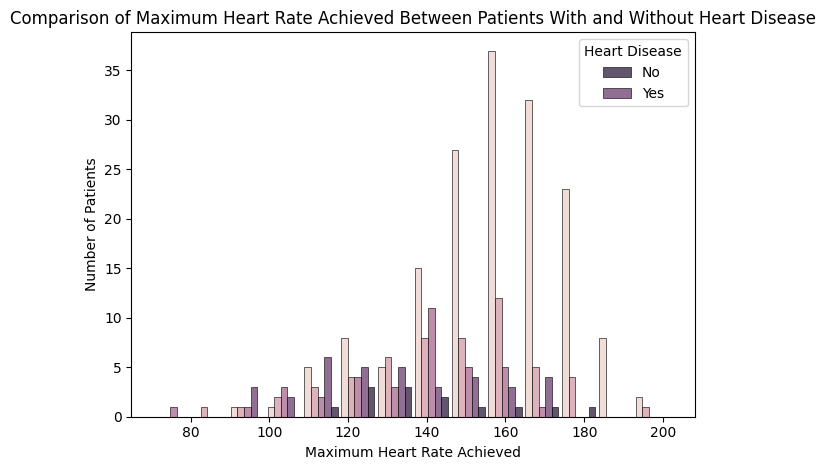

In [12]:
plt.Figure(figsize= fig_size)
sns.histplot(
    data=df,
    x='thalach',
    hue=' Target',
    multiple='dodge',      # place the bars side-by-side
    shrink=0.9,            # make bars a bit narrower
    kde=False              
)
plt.title("Comparison of Maximum Heart Rate Achieved Between Patients With and Without Heart Disease")
plt.xlabel('Maximum Heart Rate Achieved')
plt.ylabel('Number of Patients')
plt.legend(title='Heart Disease', labels=['No', 'Yes'])
plt.tight_layout()
plt.show()
